In [ ]:
!pip install -q "xgboost>=3.0" scikit-learn pandas matplotlib seaborn

In [1]:
!git clone https://github.com/NVIDIA-AI-Blueprints/transaction-foundation-model.git

Cloning into 'transaction-foundation-model'...
remote: Enumerating objects: 205, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 205 (delta 34), reused 35 (delta 32), pack-reused 152 (from 1)
Receiving objects: 100% (205/205), 708.74 KiB | 7.62 MiB/s, done.
Resolving deltas: 100% (82/82), done.


In [ ]:
import tarfile
from pathlib import Path
import pandas as pd

In [ ]:
DATA_DIR = Path("data/TabFormer/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

TEMPORAL_SPLIT_DIR = Path("data/TabFormer/temporal_split")
TEMPORAL_SPLIT_DIR.mkdir(parents=True, exist_ok=True)


TGZ_PATH = DATA_DIR.parent / "transactions.tgz"

In [ ]:
with tarfile.open(TGZ_PATH, "r:gz") as tar:
    tar.extractall(path=DATA_DIR)

/tmp/ipykernel_1616/4180461262.py:2: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=DATA_DIR)


In [ ]:

file_path = "/content/data/TabFormer/raw/card_transaction.v1.csv"
df_sample = pd.read_csv(file_path, nrows=100000)
df_sample.to_csv(
    "/content/data/TabFormer/raw/card_transaction_100K.csv",
    index=False
)

In [ ]:
import time
import random
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.metrics import roc_auc_score, average_precision_score

import xgboost as xgb
import torch

print(f"XGBoost version: {xgb.__version__}")
print(f"GPU available:   {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU 0:           {props.name}, {props.total_memory / 1e9:.1f} GB")

XGB_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

XGBoost version: 3.4.1
GPU available:   False


In [ ]:
from pathlib import Path
import random
import numpy as np
import torch

PROJECT_ROOT = Path("/content").resolve()

RAW_CSV = (
    PROJECT_ROOT
    / "data"
    / "TabFormer"
    / "raw"
    / "card_transaction_100K.csv"
)

TEMPORAL_SPLIT_DIR = (
    PROJECT_ROOT
    / "data"
    / "TabFormer"
    / "temporal_split"
)

assert RAW_CSV.exists(), f"Raw CSV not found: {RAW_CSV}"

FEATURE_COLS = [
    "User", "Card", "Year", "Month", "Day", "Hour", "Amount",
    "Use Chip", "Merchant Name", "Merchant City", "Merchant State",
    "Zip", "MCC"
]

EVAL_SAMPLES = 10000
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

print(f"Raw CSV:  {RAW_CSV}")
print(f"Features: {len(FEATURE_COLS)}d -- {FEATURE_COLS}")

Raw CSV:  /content/data/TabFormer/raw/card_transaction_100K.csv
Features: 13d -- ['User', 'Card', 'Year', 'Month', 'Day', 'Hour', 'Amount', 'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC']


In [ ]:
import pandas as pd
import time

RAW_CSV = "/content/data/TabFormer/raw/card_transaction_100K.csv"

print("Loading TabFormer sample with pandas (CPU)...")

t0 = time.time()

raw_df = pd.read_csv(RAW_CSV)

pandas_load_time = time.time() - t0

print(f"pandas load time: {pandas_load_time:.2f}s")
print(f"Shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
print(f"Columns: {list(raw_df.columns)}")

raw_df.head(3)

Loading TabFormer sample with pandas (CPU)...
pandas load time: 0.11s
Shape: 100,000 rows x 15 columns
Columns: ['User', 'Card', 'Year', 'Month', 'Day', 'Time', 'Amount', 'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC', 'Errors?', 'Is Fraud?']


,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No


In [ ]:
print("Dataset Summary:")
print(f"  Rows:    {len(raw_df):,}")
print(f"  Columns: {raw_df.shape[1]}")
print(f"  Users:   {raw_df['User'].nunique():,}")

fraud_counts = raw_df["Is Fraud?"].value_counts()
total_fraud = int(fraud_counts.get("Yes", 0))
fraud_rate = total_fraud / len(raw_df)

print(
    f"  Fraud:   {total_fraud:,} / {len(raw_df):,} "
    f"({fraud_rate:.4%})"
)

years = raw_df["Year"]

print(f"  Years:   {years.min()} to {years.max()}")

Dataset Summary:
  Rows:    100,000
  Columns: 15
  Users:   6
  Fraud:   126 / 100,000 (0.1260%)
  Years:   1999 to 2020


In [ ]:
raw_df.head(1)

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No


In [ ]:
raw_df.columns = [c.strip() for c in raw_df.columns]

print("Creating date column for temporal splitting...")

t0 = time.time()

year_str = raw_df["Year"].astype(str)
month_str = raw_df["Month"].astype(str).str.zfill(2)
day_str = raw_df["Day"].astype(str).str.zfill(2)

date_str = year_str + "-" + month_str + "-" + day_str

raw_df["date"] = pd.to_datetime(
    date_str,
    format="%Y-%m-%d"
)

pandas_date_time = time.time() - t0

print(f"pandas date creation: {pandas_date_time:.2f}s")

Creating date column for temporal splitting...
pandas date creation: 0.12s


In [ ]:
raw_df.head(1)

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?,date
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No,2002-09-01


In [ ]:
def find_cutoff_date(df, target_ratio):
    """Find date where cumulative row count reaches target_ratio of total."""

    daily_counts = (
        df.groupby("date")
        .size()
        .reset_index(name="count")
        .sort_values("date")
    )

    daily_counts["cumulative"] = daily_counts["count"].cumsum()

    total = len(df)
    target = total * target_ratio

    cutoff_df = daily_counts[
        daily_counts["cumulative"] >= target
    ].head(1)

    return cutoff_df["date"].iloc[0]


TRAIN_RATIO = 0.8
VAL_RATIO = 0.1

train_cutoff = find_cutoff_date(raw_df, TRAIN_RATIO)
test_cutoff = find_cutoff_date(raw_df, TRAIN_RATIO + VAL_RATIO)

print(f"Train/Val cutoff: {train_cutoff.strftime('%Y-%m-%d')}")
print(f"Val/Test cutoff:  {test_cutoff.strftime('%Y-%m-%d')}")

Train/Val cutoff: 2016-12-14
Val/Test cutoff:  2018-07-16


In [ ]:
train_mask = raw_df["date"] < train_cutoff

val_mask = (
    (raw_df["date"] >= train_cutoff)
    & (raw_df["date"] < test_cutoff)
)

test_mask = raw_df["date"] >= test_cutoff


train_df = (
    raw_df[train_mask]
    .drop(columns=["date"])
    .reset_index(drop=True)
)

val_df = (
    raw_df[val_mask]
    .drop(columns=["date"])
    .reset_index(drop=True)
)

test_df = (
    raw_df[test_mask]
    .drop(columns=["date"])
    .reset_index(drop=True)
)


In [ ]:
train_df.shape

(79997, 15)

In [ ]:
# def split_stats(df):
#     n = len(df)
#     fraud = int((df["Is Fraud?"].str.lower() == "yes").sum())
#     return n, fraud, fraud / n * 100

# total = len(train_df) + len(val_df) + len(test_df)
# print(f"{'Split':<8} {'Rows':>12} {'%':>7} {'Fraud':>8} {'Fraud Rate':>12}")
# print("-" * 52)

# for name, df in [
#     ("Train", train_df),
#     ("Val", val_df),
#     ("Test", test_df)
# ]:
#     n, fraud, rate = split_stats(df)

#     print(
#         f"{name:<8} "
#         f"{n:>12,} "
#         f"{n/total*100:>6.2f}% "
#         f"{fraud:>8,} "
#         f"{rate:>11.4f}%"
#     )

# print("-" * 52)
# print(f"{'Total':<8} {total:>12,}")

In [ ]:
def split_stats(df):
    n = len(df)
    fraud = int((df["Is Fraud?"].str.lower() == "yes").sum())

    return {
        "Rows": n,
        "Percent": n / total * 100,
        "Fraud": fraud,
        "Fraud Rate": fraud / n * 100
    }


total = len(train_df) + len(val_df) + len(test_df)

stats_df = pd.DataFrame({
    "Train": split_stats(train_df),
    "Val": split_stats(val_df),
    "Test": split_stats(test_df)
}).T

stats_df

,Rows,Percent,Fraud,Fraud Rate
Train,79997.0,79.997,83.0,0.103754
Val,9993.0,9.993,33.0,0.330231
Test,10010.0,10.010,10.0,0.099900


In [ ]:
TEMPORAL_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

t0 = time.time()

for name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df)
]:
    path = TEMPORAL_SPLIT_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)

    print(f"Saved: {path} ({len(df):,} rows)")

parquet_time = time.time() - t0

print(f"\nParquet write time: {parquet_time:.2f}s")

Saved: /content/data/TabFormer/temporal_split/train.parquet (79,997 rows)
Saved: /content/data/TabFormer/temporal_split/val.parquet (9,993 rows)
Saved: /content/data/TabFormer/temporal_split/test.parquet (10,010 rows)

Parquet write time: 0.19s


# 3. visual

In [ ]:
all_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

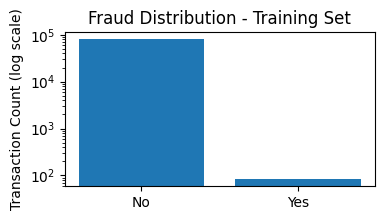

In [ ]:
fraud_counts = train_df["Is Fraud?"].value_counts()

plt.figure(figsize=(4, 2))

plt.bar(
    fraud_counts.index,
    fraud_counts.values
)

plt.yscale("log")
plt.title("Fraud Distribution - Training Set")
plt.ylabel("Transaction Count (log scale)")

plt.show()

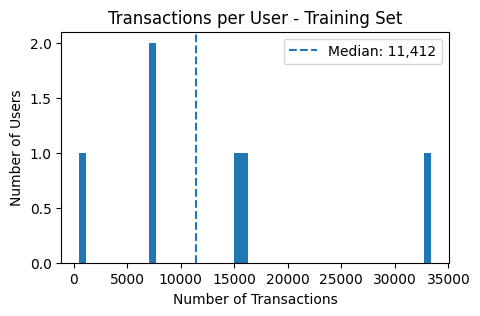

In [ ]:
txn_per_user = (
    train_df
    .groupby("User")
    .size()
)

median_txns = txn_per_user.median()

plt.figure(figsize=(5, 3))

plt.hist(
    txn_per_user,
    bins=50
)

plt.axvline(
    median_txns,
    linestyle="--",
    label=f"Median: {int(median_txns):,}"
)

plt.title("Transactions per User - Training Set")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Users")
plt.legend()

plt.show()

In [ ]:
all_df["_year"] = all_df["Year"].astype(int)
all_df["_month"] = all_df["Month"].astype(int)

monthly = (
    all_df
    .groupby(["_year", "_month"])
    .size()
    .reset_index(name="count")
)

monthly["period"] = (
    monthly["_year"].astype(str)
    + "-"
    + monthly["_month"].astype(str).str.zfill(2)
)

monthly = monthly.sort_values("period").reset_index(drop=True)

monthly.head()

,_year,_month,count,period
0,1999,11,1,1999-11
1,1999,12,78,1999-12
2,2000,1,76,2000-01
3,2000,2,64,2000-02
4,2000,3,77,2000-03


In [ ]:
print(train_cutoff)
len(monthly)

2016-12-14 00:00:00


244

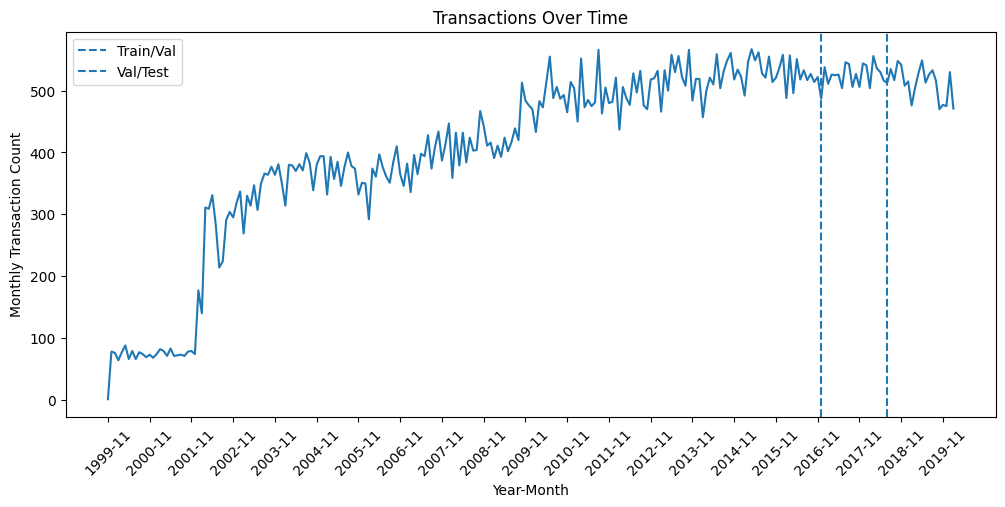

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    range(len(monthly)),
    monthly["count"]
)

train_cutoff_period = (
    f"{train_cutoff.year}-{train_cutoff.month:02d}"
)

test_cutoff_period = (
    f"{test_cutoff.year}-{test_cutoff.month:02d}"
)

train_idx = monthly.index[
    monthly["period"] == train_cutoff_period
]

test_idx = monthly.index[
    monthly["period"] == test_cutoff_period
]

if len(train_idx) > 0:
    plt.axvline(
        train_idx[0],
        linestyle="--",
        label="Train/Val"
    )

if len(test_idx) > 0:
    plt.axvline(
        test_idx[0],
        linestyle="--",
        label="Val/Test"
    )

tick_positions = range(0, len(monthly), 12)

plt.xticks(
    tick_positions,
    [monthly["period"].iloc[i] for i in tick_positions],
    rotation=45
)

plt.title("Transactions Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Monthly Transaction Count")
plt.legend()

plt.show()

In [ ]:
MCC_INDUSTRY_RANGES = [
    (0, 1499, "Agricultural"),
    (1500, 2999, "Contracted"),
    (3000, 3299, "Airlines"),
    (3300, 3499, "Car Rental"),
    (3500, 3999, "Lodging"),
    (4000, 4799, "Transportation"),
    (4800, 4999, "Utilities"),
    (5000, 5599, "Retail"),
    (5600, 5699, "Clothing"),
    (5700, 7299, "Misc Stores"),
    (7300, 7999, "Business Services"),
    (8000, 8999, "Professional"),
    (9000, 9999, "Government"),
]

def mcc_label(code):
    code = int(code)

    for lo, hi, name in MCC_INDUSTRY_RANGES:
        if lo <= code <= hi:
            return f"{name} ({code})"

    return str(code)

In [ ]:
train_df.head(1)

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No


In [ ]:
fraud_flag = (
    train_df["Is Fraud?"]
    .str.lower()
    .eq("yes")
    .astype(int)
)

mcc_stats = pd.DataFrame({
    "fraud": fraud_flag.groupby(train_df["MCC"]).sum(),
    "total": fraud_flag.groupby(train_df["MCC"]).count()
})

mcc_stats["fraud_rate"] = (
    mcc_stats["fraud"]
    / mcc_stats["total"]
    * 100
)

mcc_stats.head()

,fraud,total,fraud_rate
MCC,,,
1711,0,23,0.000000
3000,0,38,0.000000
3001,1,34,2.941176
3005,1,4,25.000000
3006,1,7,14.285714


<class 'pandas.core.frame.DataFrame'>


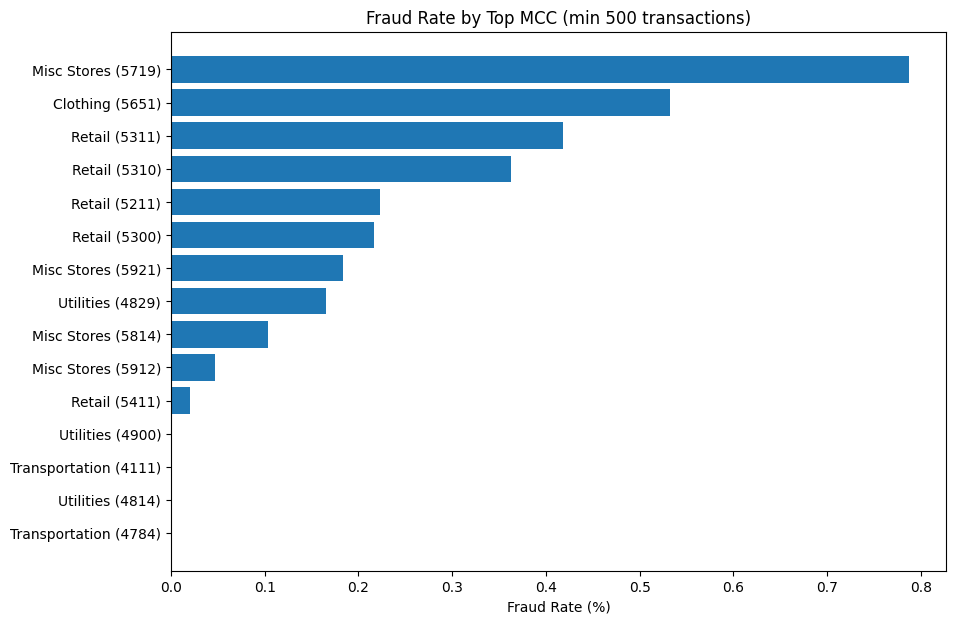

In [ ]:
min_txns = 500

top_mccs = (
    mcc_stats[mcc_stats["total"] >= min_txns].sort_values(
        "fraud_rate",
        ascending=False
    ).head(15))

print(type(top_mccs))
# display(top_mccs)

labels = [
    mcc_label(code)
    for code in top_mccs.index
]

plt.figure(figsize=(10, 7))

plt.barh(
    labels,
    top_mccs["fraud_rate"]
)

plt.gca().invert_yaxis()

plt.xlabel("Fraud Rate (%)")
plt.title(
    f"Fraud Rate by Top MCC "
    f"(min {min_txns} transactions)"
)

plt.show()

# 4. Preprocessing and Feature Engineering

In [ ]:
print("Feature engineering with pandas (CPU)...")

t0 = time.time()

for df in [train_df, val_df, test_df]:
    # Extract hour from strings like "14:35"
    df["Hour"] = (
        df["Time"]
        .str.split(":", n=1, expand=True)[0]
        .astype(int)
    )

    # Convert strings like "$1,234.56" -> 1234.56
    df["Amount"] = (
        df["Amount"]
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

    # Fraud target: Yes/1 -> 1, everything else -> 0
    df["_target"] = (
        (df["Is Fraud?"] == "Yes")
        | (df["Is Fraud?"] == "1")
    ).astype(int)

pandas_fe_time = time.time() - t0

print(f"pandas feature engineering: {pandas_fe_time:.2f}s")

Feature engineering with pandas (CPU)...
pandas feature engineering: 0.65s


In [ ]:
print("Using pandas DataFrames for downstream modeling...")

print("\n13-dimensional feature set:")

feature_summary = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "dtype": [train_df[col].dtype for col in FEATURE_COLS],
    "unique": [train_df[col].nunique() for col in FEATURE_COLS]
})

display(feature_summary)

Using pandas DataFrames for downstream modeling...

13-dimensional feature set:


,Feature,dtype,unique
0,User,int64,6
1,Card,int64,5
2,Year,int64,18
3,Month,int64,12
4,Day,int64,31
5,Hour,int64,24
6,Amount,float64,18843
7,Use Chip,object,3
8,Merchant Name,int64,1866
9,Merchant City,object,1094


# 5. Create Training and Evaluation Datasets

In [ ]:
from sklearn.model_selection import train_test_split

BALANCED_TRAIN_SIZE = 50_000
EVAL_SAMPLES = 5_000

In [ ]:
print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 79997
Val:   9993
Test:  10010


In [ ]:
for name, df in [
    ("Train", train_df),
    ("Val", val_df),
    ("Test", test_df)
]:
    print(
        name,
        "rows =", len(df),
        "fraud =", df["_target"].sum(),
        "rate =", f"{df['_target'].mean():.4%}"
    )

Train rows = 79997 fraud = 83 rate = 0.1038%
Val rows = 9993 fraud = 33 rate = 0.3302%
Test rows = 10010 fraud = 10 rate = 0.0999%


In [ ]:
print(FEATURE_COLS)
display(train_df.head(1))

['User', 'Card', 'Year', 'Month', 'Day', 'Hour', 'Amount', 'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC']


,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?,Hour,_target
0,0,0,2002,9,1,06:21,134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No,6,0


In [ ]:
def create_balanced_train_sample(
    df,
    feature_cols,
    target_col="_target",
    total_samples=50_000,
    random_state=42
):
    # Separate fraud and normal rows
    fraud_df = df[df[target_col] == 1]
    normal_df = df[df[target_col] == 0]

    # Allow fraud to make up at most 10% of requested sample
    n_fraud = min(
        len(fraud_df),
        int(total_samples * 0.10)
    )

    # Fill remaining space with normal transactions
    n_normal = min(
        len(normal_df),
        total_samples - n_fraud
    )

    # Sample fraud and normal separately
    sampled_fraud = fraud_df.sample(
        n=n_fraud,
        random_state=random_state
    )

    sampled_normal = normal_df.sample(
        n=n_normal,
        random_state=random_state
    )

    # Combine and shuffle
    sampled_df = pd.concat(
        [sampled_fraud, sampled_normal]
    ).sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    X = sampled_df[feature_cols]
    y = sampled_df[target_col].to_numpy()

    return X, y

In [ ]:
X_train, y_train = create_balanced_train_sample(
    train_df,
    FEATURE_COLS,
    total_samples=BALANCED_TRAIN_SIZE,
    random_state=RANDOM_STATE
)

In [ ]:
print("X_train shape:", X_train.shape)
print("Fraud:", y_train.sum())
print("Fraud rate:", f"{y_train.mean():.4%}")

X_train shape: (50000, 13)
Fraud: 83
Fraud rate: 0.1660%


In [ ]:
def stratified_subsample(
    df,
    feature_cols,
    target_col="_target",
    n_samples=5_000,
    random_state=42
):

    # If requested sample is larger than dataset,
    # just use the entire dataset
    if n_samples >= len(df):
        sampled_df = df.copy()

    else:
        _, sampled_df = train_test_split(
            df,
            test_size=n_samples,
            stratify=df[target_col],
            random_state=random_state
        )

    X = sampled_df[feature_cols]
    y = sampled_df[target_col].to_numpy()

    return X, y, sampled_df.index

In [ ]:
X_val, y_val, val_indices = stratified_subsample(
    val_df,
    FEATURE_COLS,
    n_samples=EVAL_SAMPLES,
    random_state=RANDOM_STATE
)

X_test, y_test, test_indices = stratified_subsample(
    test_df,
    FEATURE_COLS,
    n_samples=EVAL_SAMPLES,
    random_state=RANDOM_STATE
)

In [ ]:
print(
    "Val:",
    X_val.shape,
    "Fraud:",
    y_val.sum(),
    f"({y_val.mean():.4%})"
)

print(
    "Test:",
    X_test.shape,
    "Fraud:",
    y_test.sum(),
    f"({y_test.mean():.4%})"
)

Val: (5000, 13) Fraud: 17 (0.3400%)
Test: (5000, 13) Fraud: 5 (0.1000%)


In [ ]:
sampling_summary = pd.DataFrame({
    "Dataset": [
        "Full Train",
        "XGBoost Train",
        "Full Val",
        "Eval Val",
        "Full Test",
        "Eval Test"
    ],

    "Rows": [
        len(train_df),
        len(X_train),
        len(val_df),
        len(X_val),
        len(test_df),
        len(X_test)
    ],

    "Fraud": [
        train_df["_target"].sum(),
        y_train.sum(),
        val_df["_target"].sum(),
        y_val.sum(),
        test_df["_target"].sum(),
        y_test.sum()
    ],

    "Fraud Rate": [
        train_df["_target"].mean(),
        y_train.mean(),
        val_df["_target"].mean(),
        y_val.mean(),
        test_df["_target"].mean(),
        y_test.mean()
    ]
})

sampling_summary

,Dataset,Rows,Fraud,Fraud Rate
0,Full Train,79997,83,0.001038
1,XGBoost Train,50000,83,0.001660
2,Full Val,9993,33,0.003302
3,Eval Val,5000,17,0.003400
4,Full Test,10010,10,0.000999
5,Eval Test,5000,5,0.001000


In [ ]:
val_eval_df = val_df.loc[val_indices].reset_index(drop=True)
test_eval_df = test_df.loc[test_indices].reset_index(drop=True)

In [ ]:
val_path = TEMPORAL_SPLIT_DIR / "val_eval.parquet"
test_path = TEMPORAL_SPLIT_DIR / "test_eval.parquet"

val_eval_df.to_parquet(
    val_path,
    index=False
)

test_eval_df.to_parquet(
    test_path,
    index=False
)

print("Saved:", val_path)
print("Saved:", test_path)

Saved: /content/data/TabFormer/temporal_split/val_eval.parquet
Saved: /content/data/TabFormer/temporal_split/test_eval.parquet


In [ ]:
preprocessor = make_column_transformer(
    (
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ),
        make_column_selector(
            dtype_include=["object", "category"]
        )
    ),
    remainder="passthrough"
)
X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test)

print("Encoded shapes:")
print("Train:", X_train_enc.shape)
print("Val:  ", X_val_enc.shape)
print("Test: ", X_test_enc.shape)

Encoded shapes:
Train: (50000, 13)
Val:   (5000, 13)
Test:  (5000, 13)


# 6. XGBoost Baseline (GPU-Accelerated)

In [ ]:
import time
import xgboost as xgb

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)


# --------------------------------------------------
# XGBoost parameters
# --------------------------------------------------

XGB_PARAMS = {
    "n_estimators": 400,
    "max_depth": 8,
    "learning_rate": 0.0023,
    "colsample_bytree": 0.95,
    "min_child_weight": 12,
    "subsample": 0.673,
    "reg_alpha": 0.01,
    "reg_lambda": 0.001,
    "random_state": RANDOM_STATE,
}


# --------------------------------------------------
# Training function
# --------------------------------------------------

def train_xgb(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    params,
    name="Model"
):
    print(f"\nTraining {name}...")
    print(f"Features: {X_train.shape[1]}")
    print(f"Training samples: {X_train.shape[0]:,}")

    t0 = time.time()

    clf = xgb.XGBClassifier(
        **params,
        tree_method="hist",
        early_stopping_rounds=20,
        # eval_metric="auc"
        eval_metric = "aucpr"
    )

    clf.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    train_time = time.time() - t0

    # Validation predictions
    val_probs = clf.predict_proba(X_val)[:, 1]

    val_auc = roc_auc_score(
        y_val,
        val_probs
    )

    val_ap = average_precision_score(
        y_val,
        val_probs
    )

    # Test predictions
    test_probs = clf.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(
        y_test,
        test_probs
    )

    test_ap = average_precision_score(
        y_test,
        test_probs
    )

    print(f"\nTraining time: {train_time:.2f}s")
    print(f"Best iteration: {clf.best_iteration}")

    print("\nValidation:")
    print(f"ROC-AUC: {val_auc:.4f}")
    print(f"AP:      {val_ap:.4f}")

    print("\nTest:")
    print(f"ROC-AUC: {test_auc:.4f}")
    print(f"AP:      {test_ap:.4f}")

    metrics = {
        "val_auc": val_auc,
        "val_ap": val_ap,
        "test_auc": test_auc,
        "test_ap": test_ap
    }

    return clf, metrics

In [ ]:
clf_baseline, metrics_baseline = train_xgb(
    X_train_enc,
    y_train,
    X_val_enc,
    y_val,
    X_test_enc,
    y_test,
    params=XGB_PARAMS,
    name="XGBoost Baseline"
)


Training XGBoost Baseline...
Features: 13
Training samples: 50,000

Training time: 0.62s
Best iteration: 0

Validation:
ROC-AUC: 0.8692
AP:      0.0129

Test:
ROC-AUC: 0.8630
AP:      0.0036


# 7. Baseline Reference for NB05

In [ ]:
test_auc = metrics_baseline["test_auc"]
test_ap = metrics_baseline["test_ap"]

baseline_metrics = pd.DataFrame({
    "Metric": ["Test AUROC", "Test AUPRC"],
    "Score": [test_auc, test_ap]
})



display(baseline_metrics)

,Metric,Score
0,Test AUROC,0.862963
1,Test AUPRC,0.003639


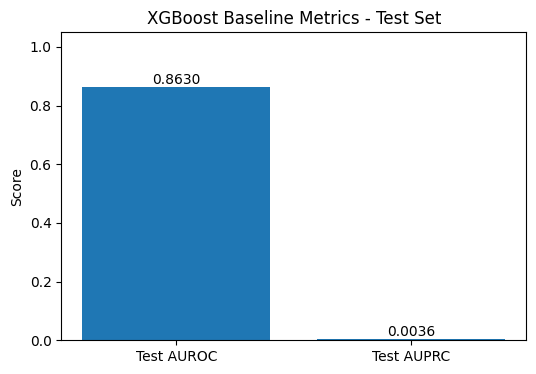

In [ ]:
plt.figure(figsize=(6, 4))

bars = plt.bar(
    baseline_metrics["Metric"],
    baseline_metrics["Score"]
)

for bar, value in zip(bars, baseline_metrics["Score"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("XGBoost Baseline Metrics - Test Set")

plt.show()

In [ ]:
y_train.sum(), len(y_train),
y_val.sum(), len(y_val),
y_test.sum(), len(y_test)

(np.int64(5), 5000)